<a href="https://colab.research.google.com/github/JeissonCu/TareasPucp/blob/main/Tarea_3_Grupo_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GRUPO 1 - INTEGRANTES:

* Estefania Chauca Alarcón
* Jose Luis Jr Vargas Rodas
* Valeria Arias Mosquito
* Isabel Salazar Mendoza
* Jarinson Castro Vargas
* Jeisson Enrique Cueva Caro

# Clasificación de comentarios de cine. Clasificación binaria


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

# Estilo de las gráficas
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
sns.set_palette("husl")


En este ejemplo aprenderás a clasificar comentarios de cine en **positivas** y **negativas**, solo a partir del texto de la comentario.

El conjunto de prueba ya viene preprocesado: las comentarios (secuencias de palabras) se han convertido en secuencias de enteros, donde cada entero representa una palabra concreta de un diccionario.


In [ ]:
from tensorflow.keras.datasets import imdb

# Cargar comentarios IMDB (num_words=10000 = 10 000 palabras más frecuentes)
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step



El argumento `num_words=10000` significa que solo conservamos las **10 000 palabras más frecuentes** en los datos de entrenamiento. Las palabras raras se descartan. Así trabajamos con vectores de tamaño manejable.

Las variables `train_data` y `test_data` son listas de comentarios; cada comentario es una lista de índices de palabras (codifica una secuencia de palabras). `train_labels` y `test_labels` son listas de 0 y 1, donde **0** es **negativo** y **1** es **positivo**:


In [ ]:
print("train_data:", type(train_data), train_data.shape)
print("train_labels:", type(train_labels), train_labels.shape)
print("test_data:", type(test_data), test_data.shape)
print("test_labels:", type(test_labels), test_labels.shape)


train_data: <class 'numpy.ndarray'> (25000,)
train_labels: <class 'numpy.ndarray'> (25000,)
test_data: <class 'numpy.ndarray'> (25000,)
test_labels: <class 'numpy.ndarray'> (25000,)


In [ ]:
train_data[6]


[1,
 6740,
 365,
 1234,
 5,
 1156,
 354,
 11,
 14,
 5327,
 6638,
 7,
 1016,
 2,
 5940,
 356,
 44,
 4,
 1349,
 500,
 746,
 5,
 200,
 4,
 4132,
 11,
 2,
 9363,
 1117,
 1831,
 7485,
 5,
 4831,
 26,
 6,
 2,
 4183,
 17,
 369,
 37,
 215,
 1345,
 143,
 2,
 5,
 1838,
 8,
 1974,
 15,
 36,
 119,
 257,
 85,
 52,
 486,
 9,
 6,
 2,
 8564,
 63,
 271,
 6,
 196,
 96,
 949,
 4121,
 4,
 2,
 7,
 4,
 2212,
 2436,
 819,
 63,
 47,
 77,
 7175,
 180,
 6,
 227,
 11,
 94,
 2494,
 2,
 13,
 423,
 4,
 168,
 7,
 4,
 22,
 5,
 89,
 665,
 71,
 270,
 56,
 5,
 13,
 197,
 12,
 161,
 5390,
 99,
 76,
 23,
 2,
 7,
 419,
 665,
 40,
 91,
 85,
 108,
 7,
 4,
 2084,
 5,
 4773,
 81,
 55,
 52,
 1901]

/tmp/ipykernel_737/615939726.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([review_lengths, test_lengths], labels=['Entrenamiento', 'Prueba'])


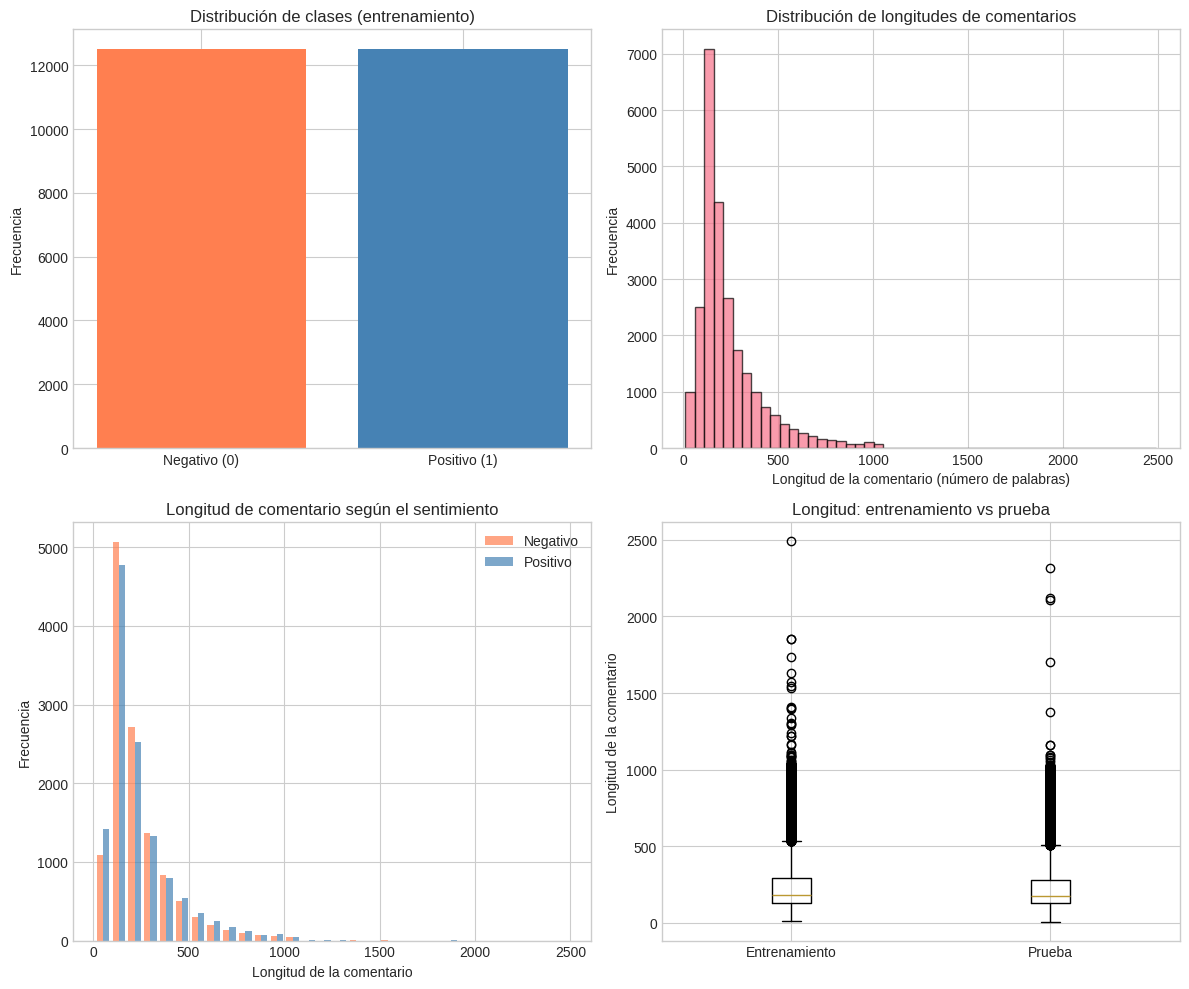

In [ ]:
# Exploración visual de los datos
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Distribución de clases (positivo vs negativo)
class_counts = pd.Series(train_labels).value_counts().sort_index()
axes[0, 0].bar(['Negativo (0)', 'Positivo (1)'], class_counts.values, color=['coral', 'steelblue'])
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de clases (entrenamiento)')

# 2. Distribución de la longitud de las comentarios
review_lengths = [len(seq) for seq in train_data]
axes[0, 1].hist(review_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Longitud de la comentario (número de palabras)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Distribución de longitudes de comentarios')

# 3. Longitud por clase
neg_lengths = [len(seq) for seq, lbl in zip(train_data, train_labels) if lbl == 0]
pos_lengths = [len(seq) for seq, lbl in zip(train_data, train_labels) if lbl == 1]
axes[1, 0].hist([neg_lengths, pos_lengths], bins=30, label=['Negativo', 'Positivo'], alpha=0.7, color=['coral', 'steelblue'])
axes[1, 0].set_xlabel('Longitud de la comentario')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Longitud de comentario según el sentimiento')
axes[1, 0].legend()

# 4. Entrenamiento vs prueba: comparación de longitud
test_lengths = [len(seq) for seq in test_data]
axes[1, 1].boxplot([review_lengths, test_lengths], labels=['Entrenamiento', 'Prueba'])
axes[1, 1].set_ylabel('Longitud de la comentario')
axes[1, 1].set_title('Longitud: entrenamiento vs prueba')

plt.tight_layout()
plt.show()


Llamaremos **secuencia** a cada texto que representa un comentario. Las secuencias son números que representan palabras distintas. Al limitarnos a las 10 000 palabras más frecuentes, ningún índice supera 10 000 (salvo el token de palabras fuera del vocabulario, que se ignora en la vectorización):


In [ ]:
max([max(sequence) for sequence in train_data])


9999

Puedes decodificar rápidamente una de estas comentarios a palabras en inglés:


In [ ]:
# word_index: diccionario palabra -> índice entero
word_index = imdb.get_word_index()
print(type(word_index), len(word_index))
# print(word_index.keys())
i = 0
for item in word_index.items():
    print(item)
    i = i + 1
    if(i > 4):
        break



1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
<class 'dict'> 88584
('fawn', 34701)
('tsukino', 52006)
('nunnery', 52007)
('sonja', 16816)
('vani', 63951)


In [ ]:
train_data[6]


[1,
 6740,
 365,
 1234,
 5,
 1156,
 354,
 11,
 14,
 5327,
 6638,
 7,
 1016,
 2,
 5940,
 356,
 44,
 4,
 1349,
 500,
 746,
 5,
 200,
 4,
 4132,
 11,
 2,
 9363,
 1117,
 1831,
 7485,
 5,
 4831,
 26,
 6,
 2,
 4183,
 17,
 369,
 37,
 215,
 1345,
 143,
 2,
 5,
 1838,
 8,
 1974,
 15,
 36,
 119,
 257,
 85,
 52,
 486,
 9,
 6,
 2,
 8564,
 63,
 271,
 6,
 196,
 96,
 949,
 4121,
 4,
 2,
 7,
 4,
 2212,
 2436,
 819,
 63,
 47,
 77,
 7175,
 180,
 6,
 227,
 11,
 94,
 2494,
 2,
 13,
 423,
 4,
 168,
 7,
 4,
 22,
 5,
 89,
 665,
 71,
 270,
 56,
 5,
 13,
 197,
 12,
 161,
 5390,
 99,
 76,
 23,
 2,
 7,
 419,
 665,
 40,
 91,
 85,
 108,
 7,
 4,
 2084,
 5,
 4773,
 81,
 55,
 52,
 1901]

In [ ]:
# Decodificamos las comentarios
# Nota: al crear word_index los índices se desplazan 3 posiciones
# porque 0, 1 y 2 están reservados para relleno, inicio de secuencia y desconocido.
# La comentario con índice 6 se lee en inglés (tras el desplazamiento)

# Creamos el diccionario inverso para decodificar los índices a palabras
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in train_data[6]])

In [ ]:
decoded_review


"? lavish production values and solid performances in this straightforward adaption of jane ? satirical classic about the marriage game within and between the classes in ? 18th century england northam and paltrow are a ? mixture as friends who must pass through ? and lies to discover that they love each other good humor is a ? virtue which goes a long way towards explaining the ? of the aged source material which has been toned down a bit in its harsh ? i liked the look of the film and how shots were set up and i thought it didn't rely too much on ? of head shots like most other films of the 80s and 90s do very good results"

In [ ]:
# Si dudas del desplazamiento de 3, prueba sin él:
decoded_review = ' '.join([reverse_word_index.get(i, '?') for i in train_data[6]])


In [ ]:
decoded_review


"the boiled full involving to impressive boring this as murdering naschy br villain and suggestion need has of costumes b message to may of props this and concentrates concept issue skeptical to god's he is and unfolds movie women like isn't surely i'm and to toward in here's for from did having because very quality it is and starship really book is both too worked carl of and br of reviewer closer figure really there will originals things is far this make mistakes and was couldn't of few br of you to don't female than place she to was between that nothing dose movies get are and br yes female just its because many br of overly to descent people time very bland"

## Preparación de los datos


No podemos alimentar la red directamente con `train_data` y `test_data` (listas de enteros). Hay que convertirlas en **tensores**.

- Podríamos **rellenar** (*pad*) las listas para que tengan la misma longitud y obtener un tensor entero de forma `(muestras, índices_palabra)`.
- Podríamos **codificar en one-hot** cada lista como un vector de 0 y 1. Por ejemplo, la secuencia `[3, 5]` se convertiría en un vector de 10 000 dimensiones todo ceros salvo en las posiciones 3 y 5, que serían 1. Entonces la primera capa podría ser una capa `Dense` que procesa vectores en punto flotante.

Vectorizaremos los datos con codificación one-hot.


In [ ]:
import numpy as np

def vectorize_sequences(sequences, dimension=10000):
    # Matriz de ceros de forma (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        # p. ej. ponemos 1.0 en la posición 389,
        # si una palabra tiene índice 389 en word_index.
        # modelo bolsa de palabras (se profundizará más adelante)
        results[i, sequence] = 1.  # poner a 1 los índices correspondientes

    return results

# Datos de entrenamiento vectorizados
x_train = vectorize_sequences(train_data)
print("forma de x_train: ", x_train.shape)
# Datos de prueba vectorizados
x_test = vectorize_sequences(test_data)
print("forma de x_test: ", x_test.shape)


forma de x_train:  (25000, 10000)
forma de x_test:  (25000, 10000)


Así lucen las muestras ahora:


In [ ]:
x_train.shape


(25000, 10000)

In [ ]:
print("len x[0]:", len(x_train[0]),"\n", x_train[0])
print("len x[10000]:", len(x_train[10000]),"\n", x_train[0])


len x[0]: 10000 
 [0. 1. 1. ... 0. 0. 0.]
len x[10000]: 10000 
 [0. 1. 1. ... 0. 0. 0.]


También debemos vectorizar las etiquetas, de forma directa:


In [ ]:
# Etiquetas vectorizadas
import numpy as np
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')


In [ ]:
print(y_train[0:8])


[1. 0. 0. 1. 0. 0. 1. 0.]


Los datos ya están listos para alimentar una red neuronal.


## Construcción de la red


Los datos de entrada son vectores y las etiquetas escalares (0 o 1). Una arquitectura que suele funcionar bien es una pila de capas totalmente conectadas (`Dense`) con activación `relu`, por ejemplo `Dense(16, activation='relu')`.

Cada capa `Dense` con `relu` implementa la cadena:

`salida = relu(dot(W, entrada) + b)`

Con 16 unidades ocultas, la matriz `W` tiene forma `(dimensión_entrada, 16)`; el producto con `W` proyecta los datos a un espacio de 16 dimensiones (luego se suma el sesgo `b` y se aplica `relu`). Aquí la dimensión de entrada es 10 000. Hay 25 000 muestras de dimensión 10 000 cada una.

Hay dos decisiones clave en esta pila densa:

* Cuántas capas usar.
* Cuántas **unidades ocultas** poner en cada capa.

La **sigmoide** comprime valores arbitrarios al intervalo `[0, 1]`, de modo que la salida se interpreta como probabilidad.


### Implementación en Keras:


In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Debemos elegir una **función de pérdida** y un **optimizador**. Como es clasificación binaria y la salida es una probabilidad (última capa de 1 unidad con sigmoide), lo habitual es usar `binary_crossentropy`. No es la única opción (por ejemplo `mean_squared_error`), pero la entropía cruzada suele ser la mejor cuando la salida es probabilística.

Aquí configuramos el modelo con optimizador `rmsprop` y pérdida `binary_crossentropy`. También monitorizamos la **precisión** (*accuracy*) durante el entrenamiento.


In [ ]:
model.compile(optimizer='rmsprop',   # 'adam' es una alternativa habitual
              loss='binary_crossentropy',
              metrics=['accuracy'])


Podemos pasar optimizador, pérdida y métricas como **cadenas** porque `rmsprop`, `binary_crossentropy` y `accuracy` vienen empaquetados en Keras. A veces conviene configurar el optimizador o usar funciones personalizadas de pérdida o métrica; el primero se hace pasando una **instancia** de optimizador:


In [ ]:
from tensorflow.keras import optimizers

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])


Lo segundo pasando **objetos función** como argumentos `loss` o `metrics`:


In [ ]:
from tensorflow.keras import losses
from tensorflow.keras import metrics

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])


## Validación del enfoque

Para comprobar el rendimiento en datos no vistos, creamos un **conjunto de validación** separando **10 000** muestras del entrenamiento original:


In [ ]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]


Entrenaremos el modelo durante **20 épocas** (20 pasadas completas sobre `x_train` e `y_train`), con mini-lotes de **512** muestras. Al mismo tiempo monitorizamos pérdida y precisión en las 10 000 muestras reservadas, pasando `validation_data` a `fit`:


In [ ]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - binary_accuracy: 0.7725 - loss: 0.5410 - val_binary_accuracy: 0.8634 - val_loss: 0.4122
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - binary_accuracy: 0.8915 - loss: 0.3373 - val_binary_accuracy: 0.8855 - val_loss: 0.3213
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - binary_accuracy: 0.9153 - loss: 0.2537 - val_binary_accuracy: 0.8709 - val_loss: 0.3152
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - binary_accuracy: 0.9322 - loss: 0.2065 - val_binary_accuracy: 0.8886 - val_loss: 0.2773
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - binary_accuracy: 0.9415 - loss: 0.1758 - val_binary_accuracy: 0.8872 - val_loss: 0.2763
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - binary_accuracy: 0.9499 - loss: 0.1503 - val_binary_accuracy: 0.8858 - val_loss: 0.2899
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - binary_accuracy: 0.9596 - loss: 0.1297 - val_binary_accuracy: 0.8860 - val_loss: 0.2908
Epoch 8/20
30

En CPU, cada época suele tardar menos de dos segundos; en unos 20 segundos termina el entrenamiento. Al final de cada época hay una breve pausa mientras se evalúa en validación.

La llamada a `model.fit()` devuelve un objeto `History` con un diccionario `history` con todo lo ocurrido durante el entrenamiento. Inspeccionémoslo:


In [ ]:
history_dict = history.history
history_dict.keys()


dict_keys(['binary_accuracy', 'loss', 'val_binary_accuracy', 'val_loss'])

Contiene cuatro series: una por métrica monitorizada en entrenamiento y en validación. Usemos Matplotlib para graficar pérdida y precisión de entrenamiento y validación:


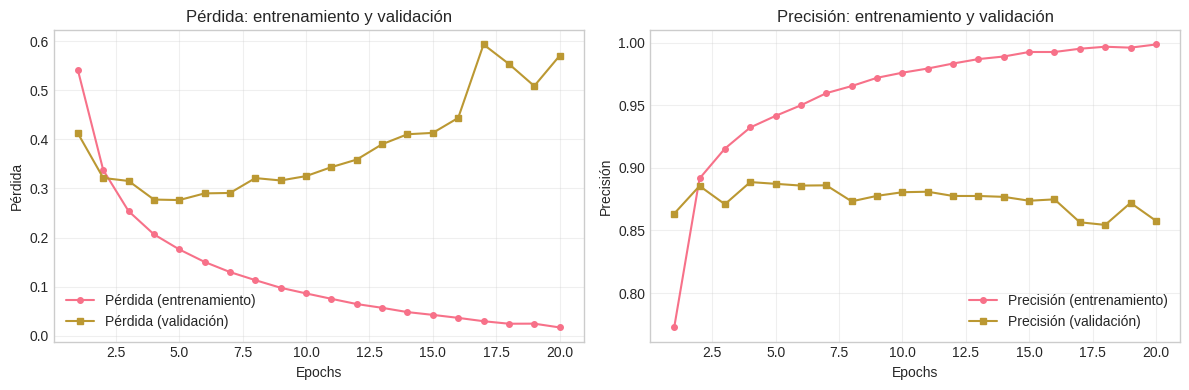

In [ ]:
# Historial: pérdida y precisión
history_dict = history.history
loss = history_dict['loss']
val_loss = history_dict['val_loss']
acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
epochs = range(1, len(loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, loss, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs, val_loss, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, acc, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs, val_acc, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Mejor época (menor pérdida en validación); útil para parada temprana
best_epoch = np.argmin(val_loss) + 1
print(f"Mejor época (menor pérdida en validación): {best_epoch}")


Mejor época (menor pérdida en validación): 5



Los puntos son pérdida y precisión de **entrenamiento**; las líneas continuas, las de **validación**.

La pérdida de entrenamiento baja en cada época y la precisión de entrenamiento sube: es lo esperable con descenso por gradientes. **No** ocurre lo mismo con validación: suelen alcanzar un máximo hacia la cuarta época. Esto ilustra el aviso anterior: un modelo que mejora en entrenamiento no siempre generaliza mejor. En rigor, aparece **sobreajuste** (*overfitting*): tras cierta época optimizamos demasiado el entrenamiento y aprendemos representaciones específicas que no generalizan fuera de él.

Para mitigarlo, podríamos parar tras unas pocas épocas. En general hay muchas técnicas anti-sobreajuste (se verán más adelante).

Entrenemos una red nueva desde cero durante **cuatro** épocas y evaluemos en el conjunto de prueba:


In [ ]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)


Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7992 - loss: 0.4996
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8980 - loss: 0.2998
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9182 - loss: 0.2307
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9314 - loss: 0.1952
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8894 - loss: 0.2788


In [ ]:
results


[0.2787759304046631, 0.8894000053405762]

Este enfoque relativamente simple alcanza alrededor del **88 %** de precisión. Con métodos más avanzados se puede acercar al **95 %**.


## Usar la red entrenada para predecir datos nuevos

Tras entrenar, interesa desplegar el modelo. La probabilidad de que una comentario sea positiva se obtiene con `predict`:


In [ ]:
# Predicciones (probabilidades)
predictions = model.predict(x_test)


782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


### Visualización de la evaluación del modelo

A continuación se visualizan las predicciones: matriz de confusión, curva ROC, distribución de probabilidades y aciertos frente a errores.


Como ves, la red es muy segura en algunas muestras (0,99 o más, o 0,01 o menos) y menos segura en otras (0,6, 0,4).


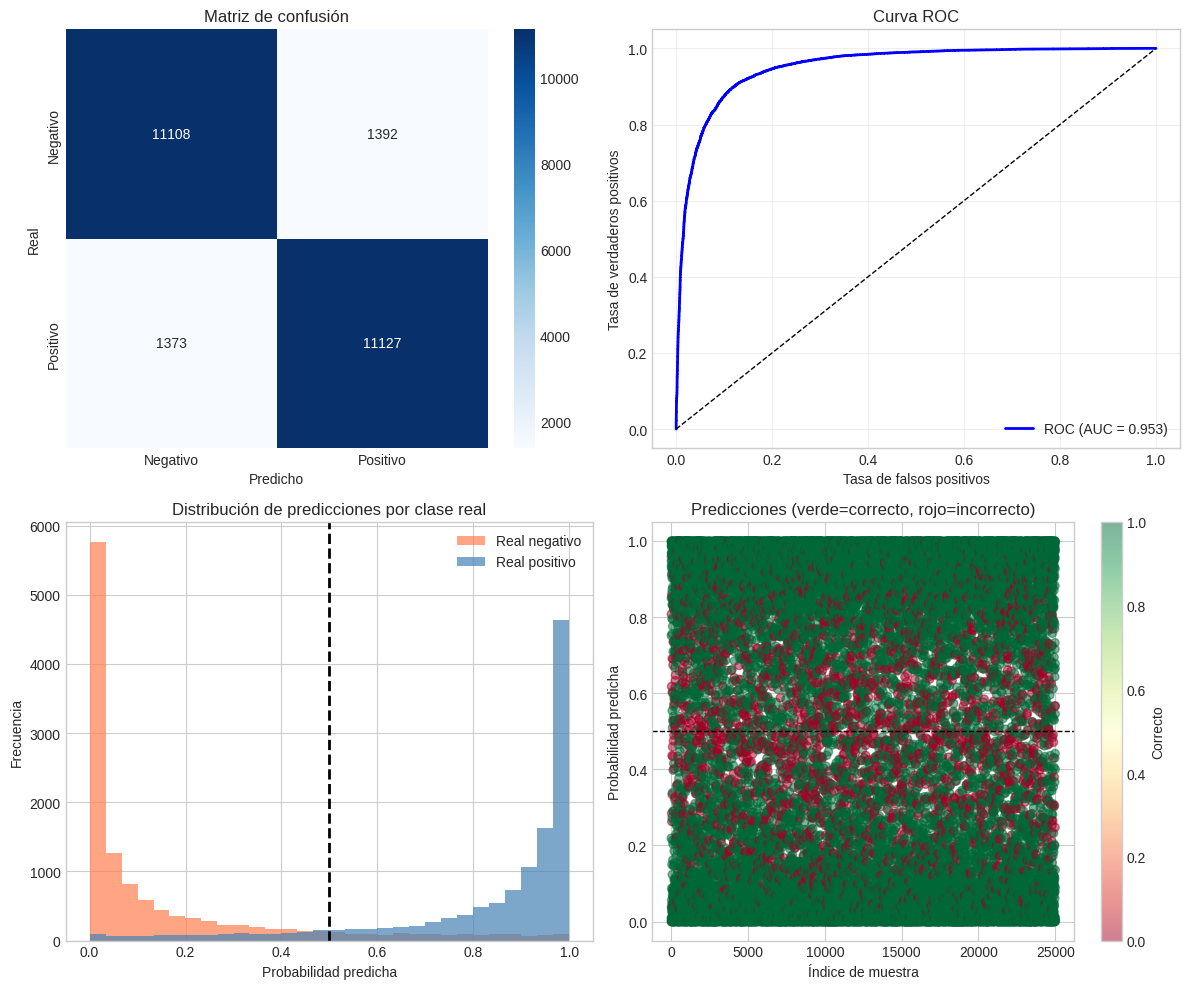

In [ ]:
# Visualización de predicciones
from sklearn.metrics import confusion_matrix, roc_curve, auc

pred_classes = (predictions.flatten() >= 0.5).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Matriz de confusión
cm = confusion_matrix(y_test, pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
axes[0, 0].set_xlabel('Predicho')
axes[0, 0].set_ylabel('Real')
axes[0, 0].set_title('Matriz de confusión')

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y_test, predictions.flatten())
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 1].set_xlabel('Tasa de falsos positivos')
axes[0, 1].set_ylabel('Tasa de verdaderos positivos')
axes[0, 1].set_title('Curva ROC')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribución de probabilidades predichas por clase real
axes[1, 0].hist(predictions[y_test == 0].flatten(), bins=30, alpha=0.7, label='Real negativo', color='coral')
axes[1, 0].hist(predictions[y_test == 1].flatten(), bins=30, alpha=0.7, label='Real positivo', color='steelblue')
axes[1, 0].axvline(x=0.5, color='black', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Probabilidad predicha')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de predicciones por clase real')
axes[1, 0].legend()

# 4. Predicciones correctas vs incorrectas
correct = pred_classes == y_test
axes[1, 1].scatter(range(len(predictions)), predictions.flatten(), c=correct, cmap='RdYlGn', alpha=0.5)
axes[1, 1].axhline(y=0.5, color='black', linestyle='--', lw=1)
axes[1, 1].set_xlabel('Índice de muestra')
axes[1, 1].set_ylabel('Probabilidad predicha')
axes[1, 1].set_title('Predicciones (verde=correcto, rojo=incorrecto)')
plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1], label='Correcto')

plt.tight_layout()
plt.show()


# Regularizers

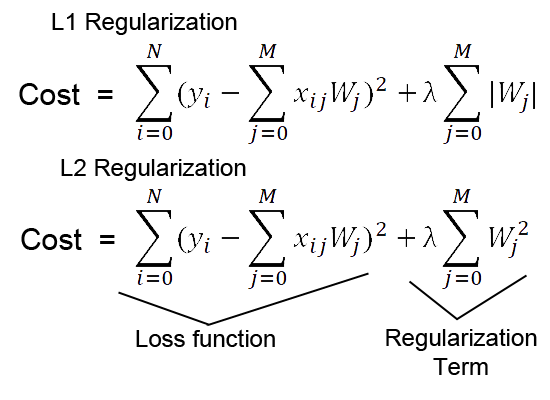

# L2

In [ ]:
from keras import regularizers
l2_model = models.Sequential()
l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001),activation='relu', input_shape=(10000,)))
l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001), activation='relu'))
l2_model.add(layers.Dense(1, activation='sigmoid'))

l2_model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
l2_model_history = l2_model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.7611 - loss: 0.6086 - val_accuracy: 0.8585 - val_loss: 0.4702
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8843 - loss: 0.3987 - val_accuracy: 0.8786 - val_loss: 0.3754
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9097 - loss: 0.3151 - val_accuracy: 0.8883 - val_loss: 0.3404
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9269 - loss: 0.2688 - val_accuracy: 0.8854 - val_loss: 0.3321
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.9372 - loss: 0.2382 - val_accuracy: 0.8712 - val_loss: 0.3709
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9447 - loss: 0.2205 - val_accuracy: 0.8835 - val_loss: 0.3394
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9527 - loss: 0.2043 - val_accuracy: 0.8821 - val_loss: 0.3533
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9569 - loss: 0.1948 - val_accuracy: 0.8834 - v

In [ ]:
l2_model_history_dict = l2_model_history.history
l2_model_history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

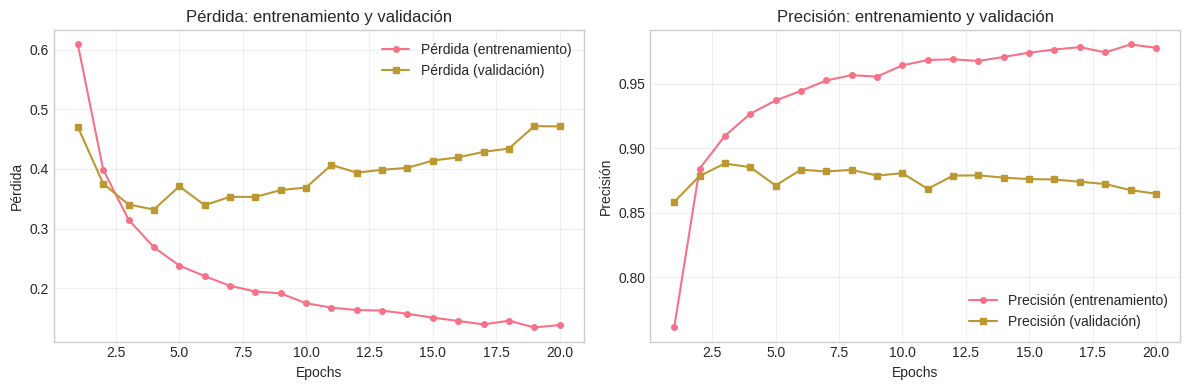

In [ ]:
# Historial: pérdida y precisión
l2_model_history_dict = l2_model_history.history
l2_loss = l2_model_history_dict['loss']
l2_val_loss = l2_model_history_dict['val_loss']
l2_acc = l2_model_history_dict['accuracy']
l2_val_acc = l2_model_history_dict['val_accuracy']
epochs = range(1, len(loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, l2_loss, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs, l2_val_loss, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, l2_acc, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs, l2_val_acc, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Comparación Modelo Original vs L2

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

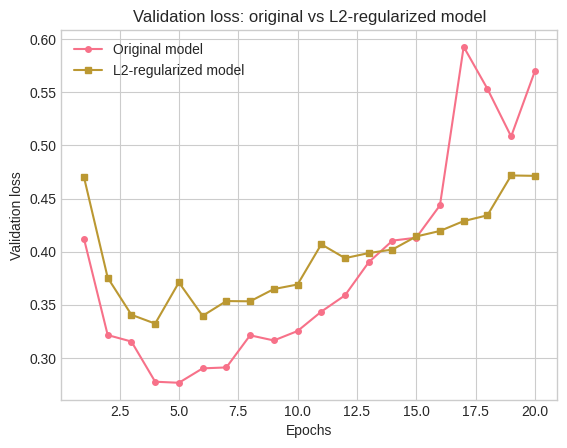

In [ ]:
l2_model_val_loss=l2_model_history_dict['val_loss']
plt.plot(epochs, val_loss, 'o-', label='Original model', markersize=4)
plt.plot(epochs, l2_val_loss, 's-', label='L2-regularized model', markersize=4)
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.title('Validation loss: original vs L2-regularized model')
plt.legend()
plt

# L1 Regularizer

In [ ]:
from keras import regularizers
l1_model = models.Sequential()
l1_model.add(layers.Dense(16, kernel_regularizer=regularizers.l1(0.001),activation='relu', input_shape=(10000,)))
l1_model.add(layers.Dense(16, kernel_regularizer=regularizers.l1(0.001), activation='relu'))
l1_model.add(layers.Dense(1, activation='sigmoid'))

l1_model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
l1_model_history = l1_model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.7442 - loss: 1.1550 - val_accuracy: 0.8391 - val_loss: 0.7091
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8434 - loss: 0.6643 - val_accuracy: 0.8471 - val_loss: 0.6491
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.8509 - loss: 0.6178 - val_accuracy: 0.8304 - val_loss: 0.6491
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8586 - loss: 0.5890 - val_accuracy: 0.8531 - val_loss: 0.6060
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8611 - loss: 0.5763 - val_accuracy: 0.8539 - val_loss: 0.5928
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.8618 - loss: 0.5690 - val_accuracy: 0.8494 - val_loss: 0.5946
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8619 - loss: 0.5601 - val_accuracy: 0.8482 - val_loss: 0.5914
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8666 - loss: 0.5493 - val_accuracy: 0.8585 - v

In [ ]:
l1_model_history_dict = l1_model_history.history
l1_model_history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

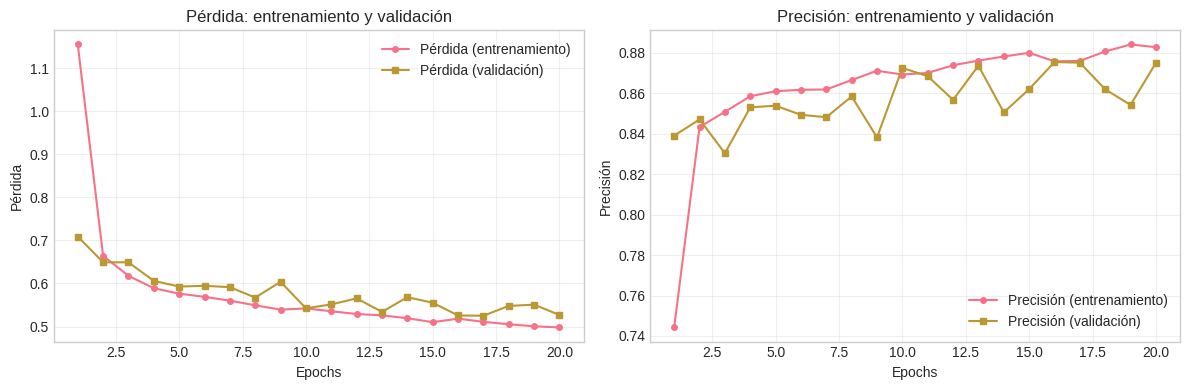

In [ ]:
# Historial: pérdida y precisión
l1_model_history_dict = l1_model_history.history
l1_loss = l1_model_history_dict['loss']
l1_val_loss = l1_model_history_dict['val_loss']
l1_acc = l1_model_history_dict['accuracy']
l1_val_acc = l1_model_history_dict['val_accuracy']
epochs = range(1, len(loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, l1_loss, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs, l1_val_loss, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, l1_acc, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs, l1_val_acc, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparación Modelo Original vs L1

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

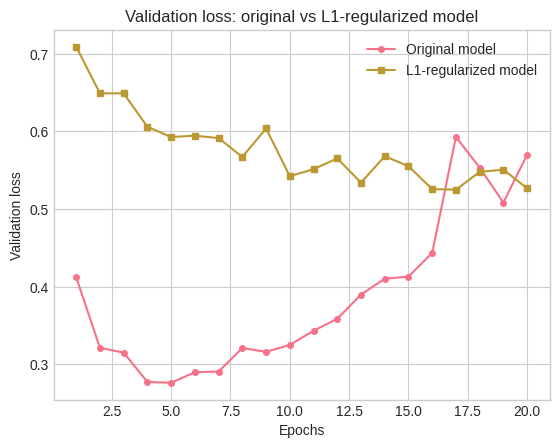

In [ ]:
l1_model_val_loss=l1_model_history_dict['val_loss']
plt.plot(epochs, val_loss, 'o-', label='Original model', markersize=4)
plt.plot(epochs, l1_val_loss, 's-', label='L1-regularized model', markersize=4)
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.title('Validation loss: original vs L1-regularized model')
plt.legend()
plt

In [ ]:
# Predicciones (probabilidades)
l1_predictions = l1_model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


## Visualization Predictions L1

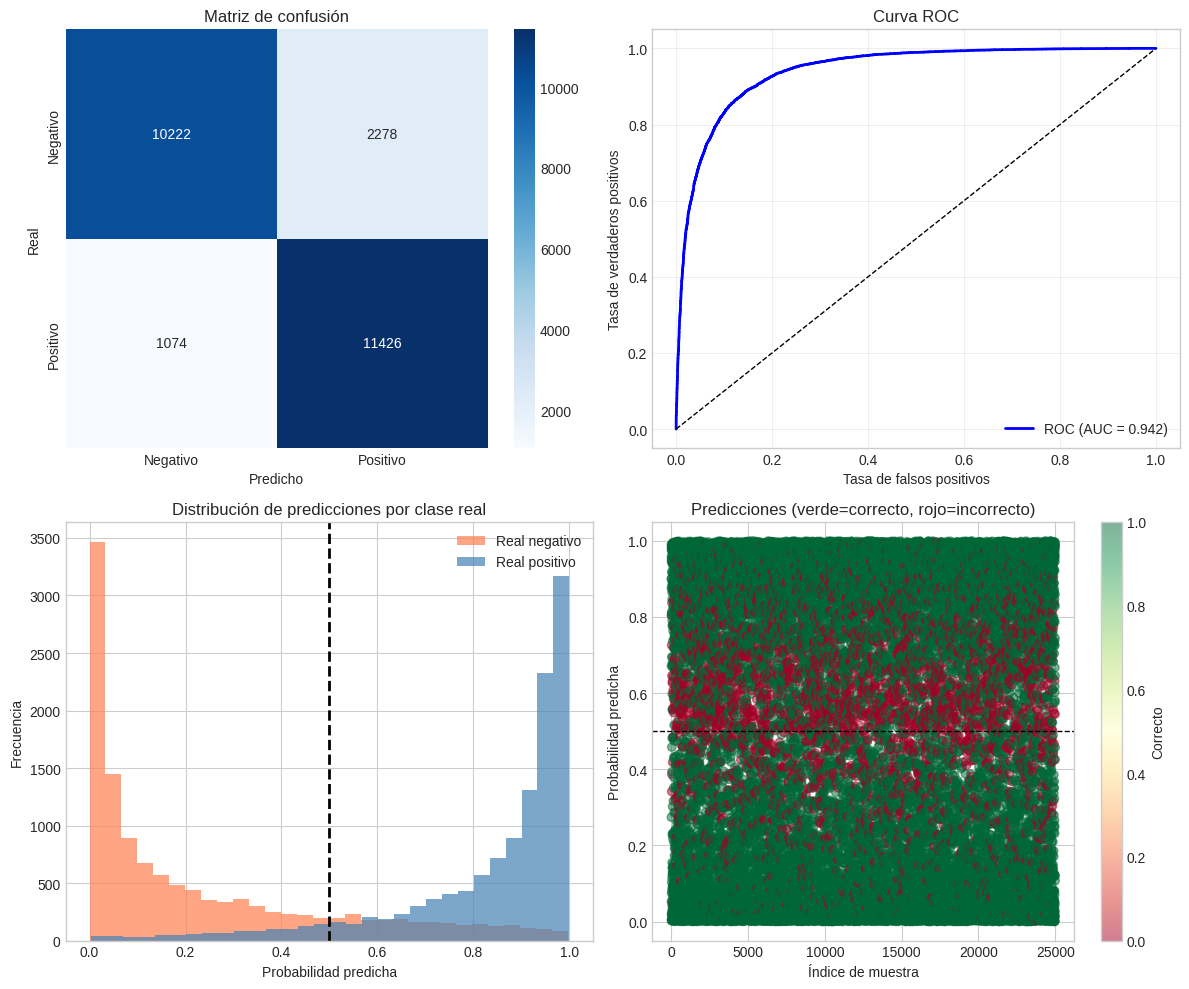

In [ ]:
# Visualización de predicciones
from sklearn.metrics import confusion_matrix, roc_curve, auc

pred_classes = (l1_predictions.flatten() >= 0.5).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Matriz de confusión
cm = confusion_matrix(y_test, pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
axes[0, 0].set_xlabel('Predicho')
axes[0, 0].set_ylabel('Real')
axes[0, 0].set_title('Matriz de confusión')

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y_test, l1_predictions.flatten())
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 1].set_xlabel('Tasa de falsos positivos')
axes[0, 1].set_ylabel('Tasa de verdaderos positivos')
axes[0, 1].set_title('Curva ROC')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribución de probabilidades predichas por clase real
axes[1, 0].hist(l1_predictions[y_test == 0].flatten(), bins=30, alpha=0.7, label='Real negativo', color='coral')
axes[1, 0].hist(l1_predictions[y_test == 1].flatten(), bins=30, alpha=0.7, label='Real positivo', color='steelblue')
axes[1, 0].axvline(x=0.5, color='black', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Probabilidad predicha')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de predicciones por clase real')
axes[1, 0].legend()

# 4. Predicciones correctas vs incorrectas
correct = pred_classes == y_test
axes[1, 1].scatter(range(len(l1_predictions)), l1_predictions.flatten(), c=correct, cmap='RdYlGn', alpha=0.5)
axes[1, 1].axhline(y=0.5, color='black', linestyle='--', lw=1)
axes[1, 1].set_xlabel('Índice de muestra')
axes[1, 1].set_ylabel('Probabilidad predicha')
axes[1, 1].set_title('Predicciones (verde=correcto, rojo=incorrecto)')
plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1], label='Correcto')

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers
from keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

# Define the L2 regularized model again
l2_model_early_stopping = models.Sequential()
l2_model_early_stopping.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001), activation='relu', input_shape=(10000,)))
l2_model_early_stopping.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001), activation='relu'))
l2_model_early_stopping.add(layers.Dense(1, activation='sigmoid'))

# Compile the model
l2_model_early_stopping.compile(optimizer='rmsprop',
                                loss='binary_crossentropy',
                                metrics=['accuracy'])

# Define Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor the validation loss
    patience=5,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity.
)

# Train the model with early stopping
l2_model_early_stopping_history = l2_model_early_stopping.fit(partial_x_train,
                                                               partial_y_train,
                                                               epochs=20, # Train for a sufficient number of epochs, early stopping will stop it earlier if needed
                                                               batch_size=512,
                                                               validation_data=(x_val, y_val),
                                                               callbacks=[early_stopping])

# Evaluate the model on the test data
results_early_stopping = l2_model_early_stopping.evaluate(x_test, y_test)
print(f"Test Loss: {results_early_stopping[0]:.4f}, Test Accuracy: {results_early_stopping[1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.7676 - loss: 0.6112 - val_accuracy: 0.8552 - val_loss: 0.5032
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8807 - loss: 0.4286 - val_accuracy: 0.8693 - val_loss: 0.4106
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9073 - loss: 0.3397 - val_accuracy: 0.8858 - val_loss: 0.3537
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9195 - loss: 0.2922 - val_accuracy: 0.8788 - val_loss: 0.3509
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9305 - loss: 0.2629 - val_accuracy: 0.8812 - val_loss: 0.3440
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9387 - loss: 0.2412 - val_accuracy: 0.8813 - val_loss: 0.3442
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9442 - loss: 0.2256 - val_accuracy: 0.8849 - val_loss: 0.3359
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9470 - loss: 0.2156 - val_accuracy: 0.8816 - v

### Training History with Early Stopping

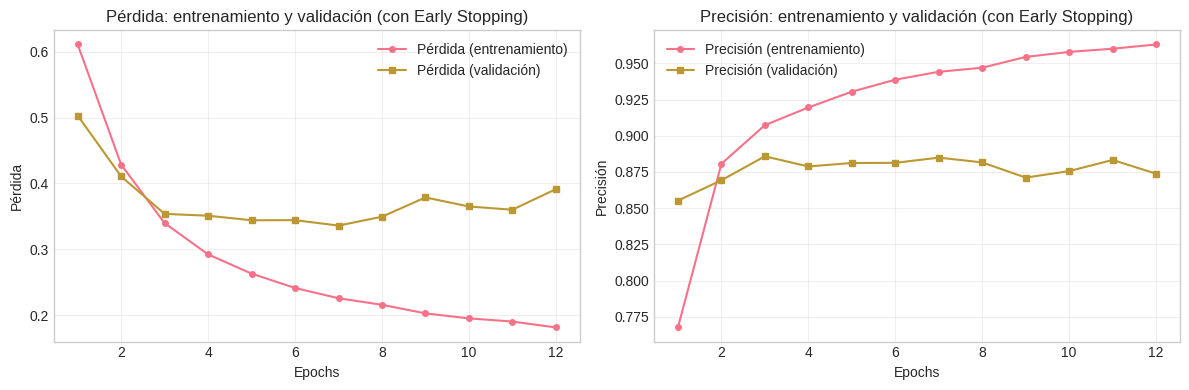

In [ ]:
# Historial: pérdida y precisión con Early Stopping
callbacks_history_dict = l2_model_early_stopping_history.history
callbacks_loss = callbacks_history_dict['loss']
callbacks_val_loss = callbacks_history_dict['val_loss']
callbacks_acc = callbacks_history_dict['accuracy']
callbacks_val_acc = callbacks_history_dict['val_accuracy']
epochs = range(1, len(callbacks_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, callbacks_loss, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs, callbacks_val_loss, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación (con Early Stopping)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, callbacks_acc, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs, callbacks_val_acc, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación (con Early Stopping)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Dropout Regularization

In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers

dropout_model = models.Sequential()
dropout_model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
dropout_model.add(layers.Dropout(0.5)) # Add dropout layer with a rate of 0.5
dropout_model.add(layers.Dense(16, activation='relu'))
dropout_model.add(layers.Dropout(0.5)) # Add another dropout layer
dropout_model.add(layers.Dense(1, activation='sigmoid'))

dropout_model.compile(optimizer='rmsprop',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

In [ ]:
dropout_model_history = dropout_model.fit(partial_x_train,
                                          partial_y_train,
                                          epochs=20,
                                          batch_size=512,
                                          validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.6185 - loss: 0.6430 - val_accuracy: 0.8360 - val_loss: 0.5606
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7414 - loss: 0.5397 - val_accuracy: 0.8659 - val_loss: 0.4571
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8010 - loss: 0.4703 - val_accuracy: 0.8800 - val_loss: 0.3936
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8415 - loss: 0.4160 - val_accuracy: 0.8797 - val_loss: 0.3595
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8701 - loss: 0.3752 - val_accuracy: 0.8869 - val_loss: 0.3307
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8930 - loss: 0.3407 - val_accuracy: 0.8849 - val_loss: 0.3235
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9100 - loss: 0.3136 - val_accuracy: 0.8814 - val_loss: 0.3067
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9225 - loss: 0.2854 - val_accuracy: 0.8841 - v

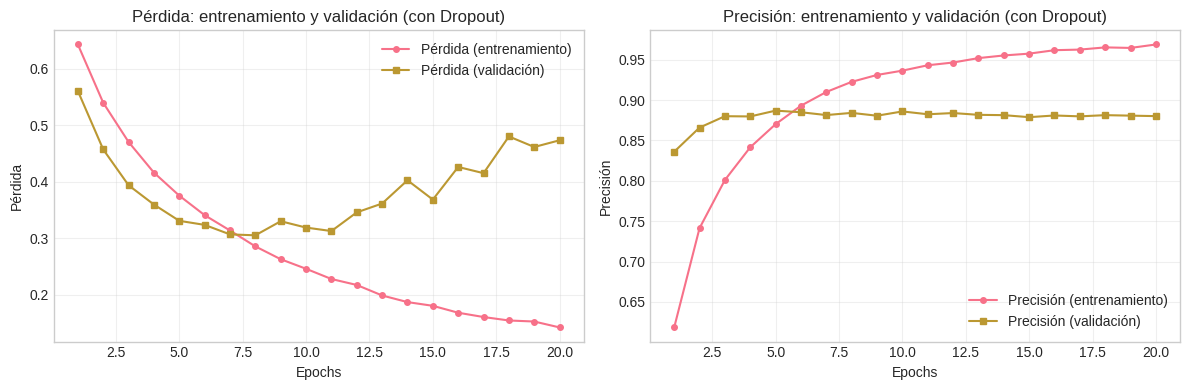

In [ ]:
# Historial: pérdida y precisión para el modelo con Dropout
dropout_history_dict = dropout_model_history.history
dropout_loss = dropout_history_dict['loss']
dropout_val_loss = dropout_history_dict['val_loss']
dropout_acc = dropout_history_dict['accuracy']
dropout_val_acc = dropout_history_dict['val_accuracy']
epochs = range(1, len(dropout_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, dropout_loss, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs, dropout_val_loss, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación (con Dropout)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, dropout_acc, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs, dropout_val_acc, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación (con Dropout)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparación de Modelos: Original vs L2 vs Dropout

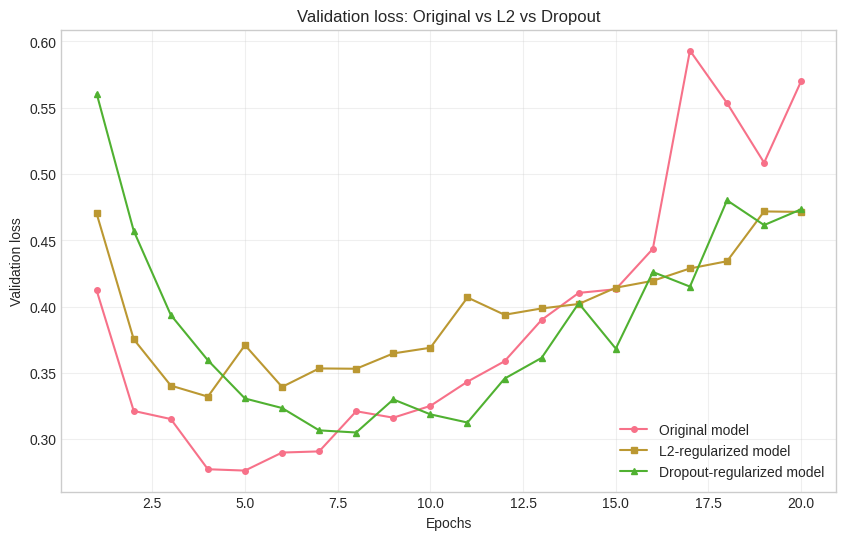

In [ ]:
dropout_val_loss = dropout_history_dict['val_loss']

plt.figure(figsize=(10, 6))
plt.plot(epochs, val_loss, 'o-', label='Original model', markersize=4)
plt.plot(epochs, l2_val_loss, 's-', label='L2-regularized model', markersize=4)
plt.plot(epochs, dropout_val_loss, '^-', label='Dropout-regularized model', markersize=4)
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.title('Validation loss: Original vs L2 vs Dropout')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# **Tarea Problema 2**

Regularización L1 y L2 aplicada a ambas capas ocultas `Dense(16)`. Se prueban 4 combinaciones de parámetros, tal como pide el enunciado.

In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers
from keras import regularizers

# 4 combinaciones de parámetros (L1, L2) pedidas en el enunciado
l1_l2_pairs = [
    (0.01, 0.01),
    (0.02, 0.02),
    (0.01, 0.02),
    (0.02, 0.01),
]

l1_l2_histories = {}

for l1_val, l2_val in l1_l2_pairs:
    print(f"\n--- Entrenando modelo con L1={l1_val}, L2={l2_val} ---")

    model_l1l2 = models.Sequential()
    model_l1l2.add(layers.Dense(16,
                                 kernel_regularizer=regularizers.l1_l2(l1=l1_val, l2=l2_val),
                                 activation='relu',
                                 input_shape=(10000,)))
    model_l1l2.add(layers.Dense(16,
                                 kernel_regularizer=regularizers.l1_l2(l1=l1_val, l2=l2_val),
                                 activation='relu'))
    model_l1l2.add(layers.Dense(1, activation='sigmoid'))

    model_l1l2.compile(optimizer='rmsprop',
                        loss='binary_crossentropy',
                        metrics=['accuracy'])

    history = model_l1l2.fit(partial_x_train,
                              partial_y_train,
                              epochs=20,
                              batch_size=512,
                              validation_data=(x_val, y_val),
                              verbose=0)

    l1_l2_histories[(l1_val, l2_val)] = history.history

print("\nEntrenamiento de las 4 combinaciones completado.")



--- Entrenando modelo con L1=0.01, L2=0.01 ---

--- Entrenando modelo con L1=0.02, L2=0.02 ---

--- Entrenando modelo con L1=0.01, L2=0.02 ---

--- Entrenando modelo con L1=0.02, L2=0.01 ---

Entrenamiento de las 4 combinaciones completado.


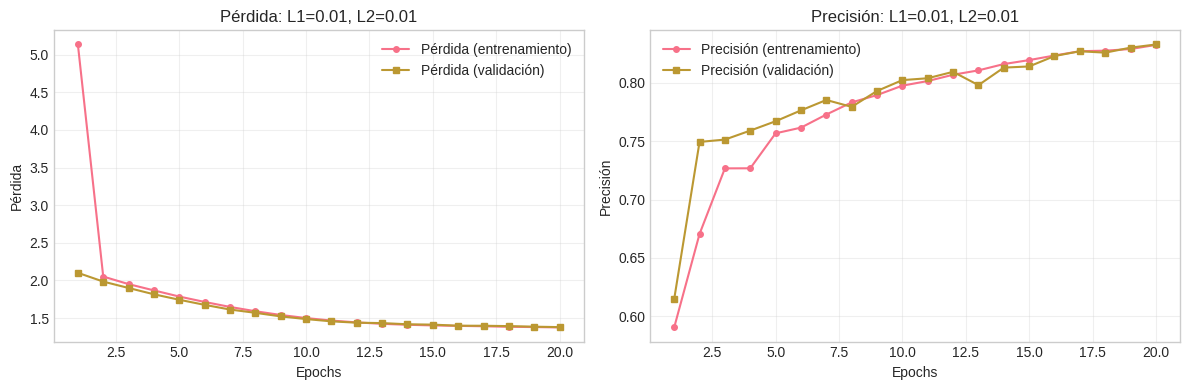

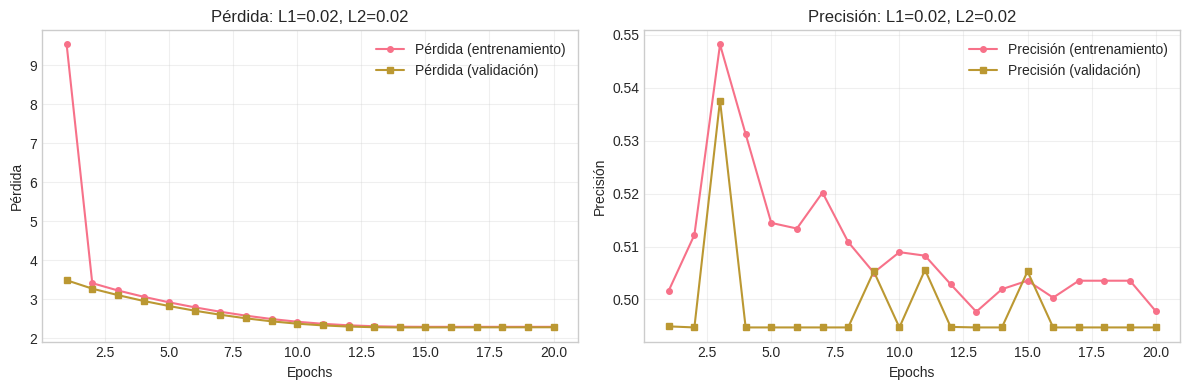

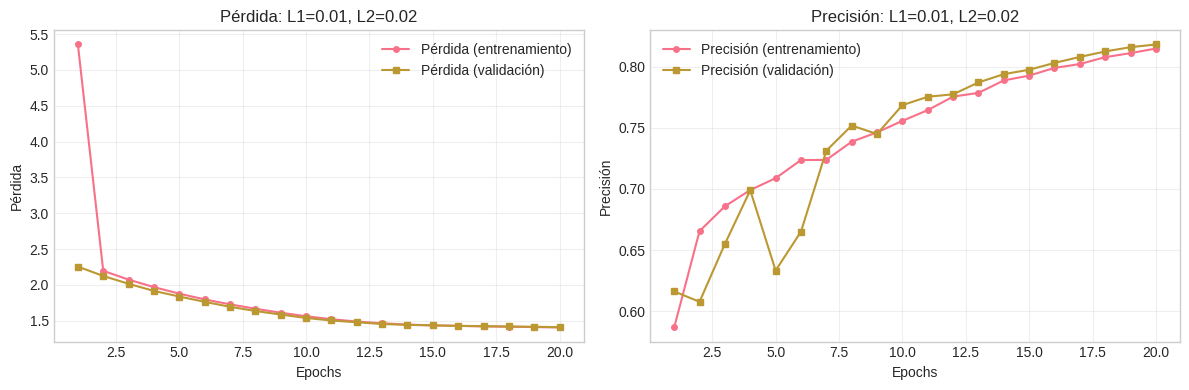

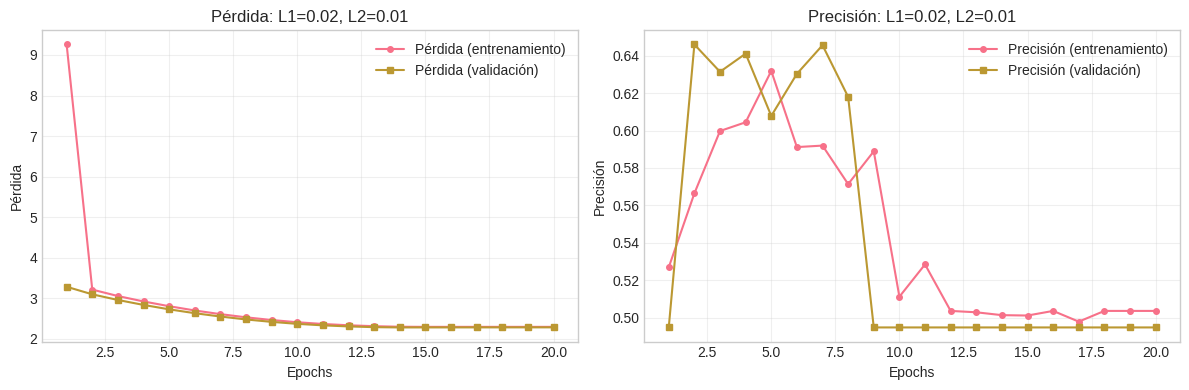

In [ ]:
# Gráficas de pérdida y precisión para cada una de las 4 combinaciones
epochs_range = range(1, 21)

for (l1_val, l2_val), hist in l1_l2_histories.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs_range, hist['loss'], 'o-', label='Pérdida (entrenamiento)', markersize=4)
    axes[0].plot(epochs_range, hist['val_loss'], 's-', label='Pérdida (validación)', markersize=4)
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Pérdida')
    axes[0].set_title(f'Pérdida: L1={l1_val}, L2={l2_val}')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_range, hist['accuracy'], 'o-', label='Precisión (entrenamiento)', markersize=4)
    axes[1].plot(epochs_range, hist['val_accuracy'], 's-', label='Precisión (validación)', markersize=4)
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Precisión')
    axes[1].set_title(f'Precisión: L1={l1_val}, L2={l2_val}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


**INTERPRETACIÓN** :


> Observamos que





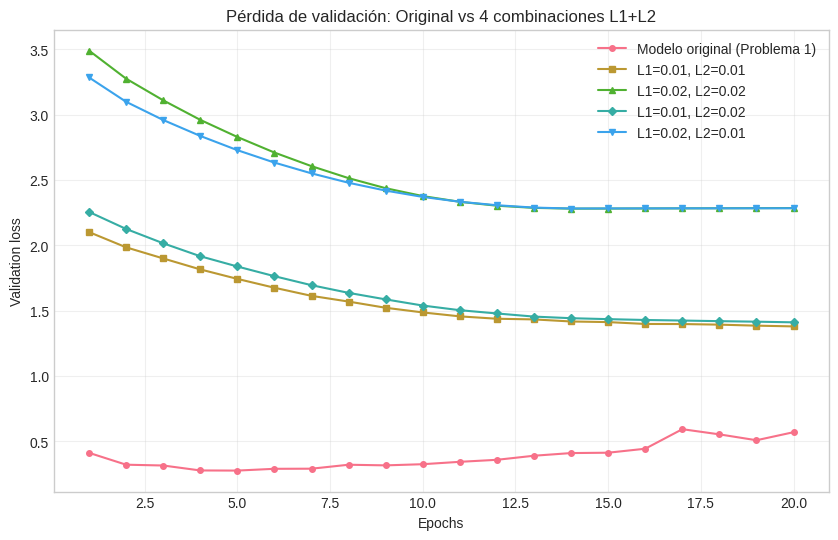

In [ ]:
# Comparación de la pérdida de validación: modelo original vs las 4 combinaciones L1+L2
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, val_loss, 'o-', label='Modelo original (Problema 1)', markersize=4)

markers = ['s-', '^-', 'D-', 'v-']
for marker, ((l1_val, l2_val), hist) in zip(markers, l1_l2_histories.items()):
    plt.plot(epochs_range, hist['val_loss'], marker, label=f'L1={l1_val}, L2={l2_val}', markersize=4)

plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.title('Pérdida de validación: Original vs 4 combinaciones L1+L2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**CONCLUSIONES PROBLEMA 2**



> Al aplicar regularización combinada L1+L2 en ambas capas ocultas con las 4 combinaciones de parámetros pedidas —(0.01,0.01), (0.02,0.02), (0.01,0.02), (0.02,0.01)—, se observó un efecto distinto al esperado:

> En lugar de un overfitting moderado, los cuatro modelos presentan underfitting severo. La pérdida de validación se estabiliza en valores muy altos (entre 1.4 y 3.5) frente al 0.28–0.57 del modelo original, y la precisión de validación no logra superar el 83%, quedando en algunos casos (L1=0.02, L2=0.02) estancada cerca del 50%, equivalente a una clasificación aleatoria.

> El factor determinante parece ser el coeficiente L1: las combinaciones con L1=0.01 logran cierto aprendizaje (accuracy ~80–83%), mientras que subir L1 a 0.02 penaliza los pesos tan fuertemente que el modelo pierde casi toda su capacidad de ajuste, sin importar el valor de L2 asociado. En conclusión, a estas magnitudes de regularización la penalización es excesiva para una arquitectura tan pequeña (Dense(16)): sí elimina el overfitting, pero al costo de que el modelo ya no logra aprender lo suficiente del conjunto de entrenamiento, resultando en un desempeño general muy inferior al modelo original.











# **Tarea Problema 3**

Dropout después de la primera y segunda capa oculta `Dense`, probando con 25% y 10% de la señal, tal como pide el enunciado.

In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers

# Tasas de Dropout pedidas en el enunciado: 25% y 10%
dropout_rates = [0.25, 0.10]

dropout_histories = {}

for rate in dropout_rates:
    print(f"\n--- Entrenando modelo con Dropout={rate} ---")

    model_dropout = models.Sequential()
    model_dropout.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
    model_dropout.add(layers.Dropout(rate))
    model_dropout.add(layers.Dense(16, activation='relu'))
    model_dropout.add(layers.Dropout(rate))
    model_dropout.add(layers.Dense(1, activation='sigmoid'))

    model_dropout.compile(optimizer='rmsprop',
                           loss='binary_crossentropy',
                           metrics=['accuracy'])

    history = model_dropout.fit(partial_x_train,
                                 partial_y_train,
                                 epochs=20,
                                 batch_size=512,
                                 validation_data=(x_val, y_val),
                                 verbose=0)

    dropout_histories[rate] = history.history

print("\nEntrenamiento con Dropout 25% y 10% completado.")



--- Entrenando modelo con Dropout=0.25 ---

--- Entrenando modelo con Dropout=0.1 ---

Entrenamiento con Dropout 25% y 10% completado.


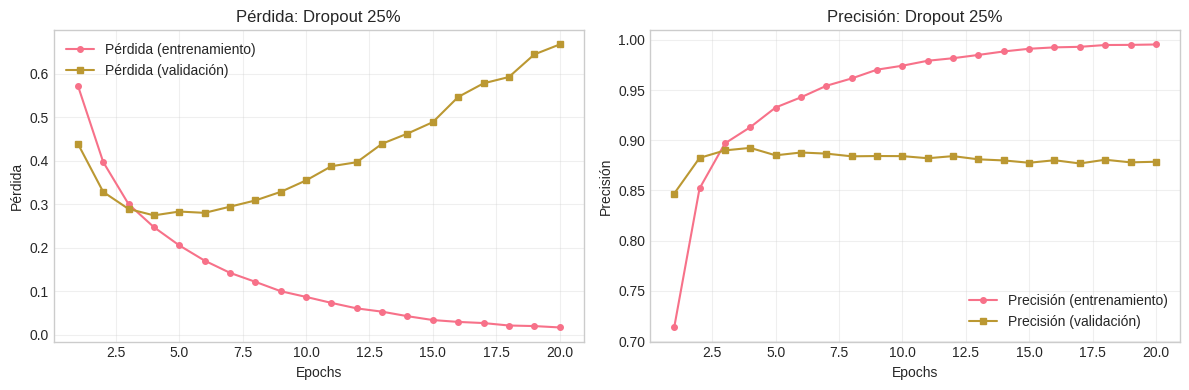

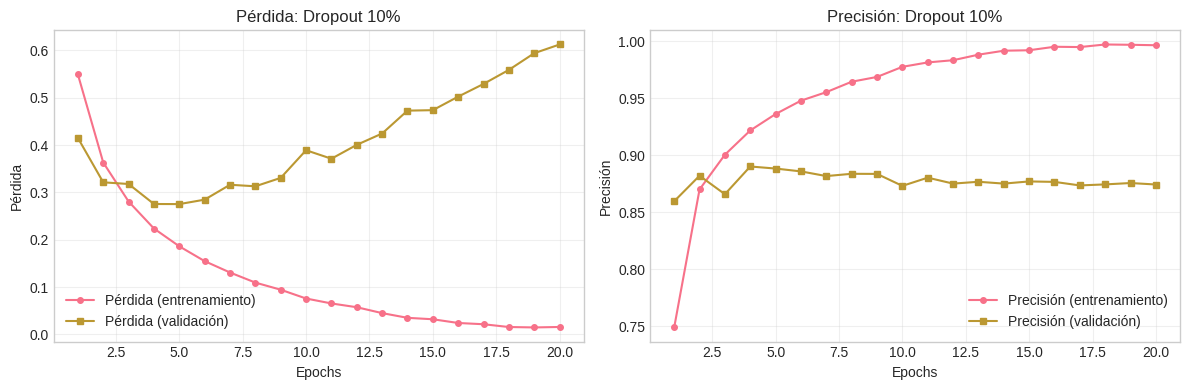

In [ ]:
# Gráficas de pérdida y precisión para cada tasa de Dropout
for rate, hist in dropout_histories.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs_range, hist['loss'], 'o-', label='Pérdida (entrenamiento)', markersize=4)
    axes[0].plot(epochs_range, hist['val_loss'], 's-', label='Pérdida (validación)', markersize=4)
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Pérdida')
    axes[0].set_title(f'Pérdida: Dropout {int(rate*100)}%')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_range, hist['accuracy'], 'o-', label='Precisión (entrenamiento)', markersize=4)
    axes[1].plot(epochs_range, hist['val_accuracy'], 's-', label='Precisión (validación)', markersize=4)
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Precisión')
    axes[1].set_title(f'Precisión: Dropout {int(rate*100)}%')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


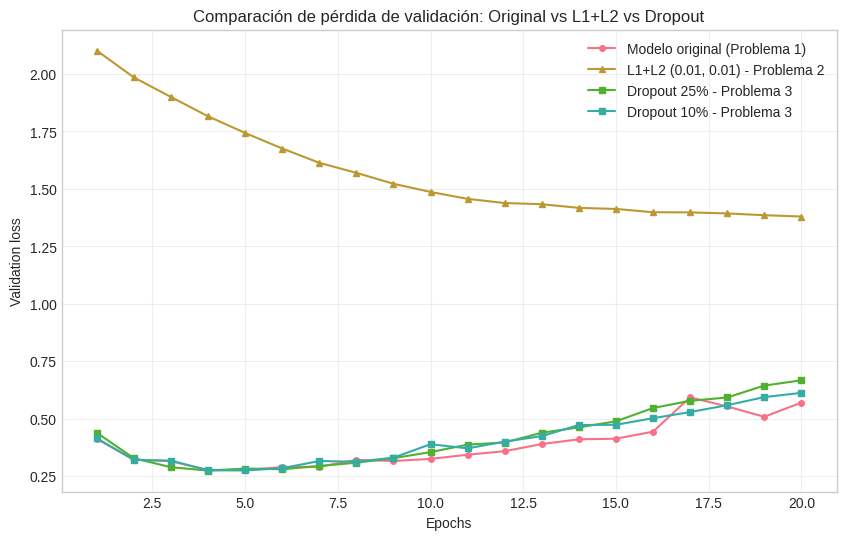

In [ ]:
# Comparación final: Original (Problema 1) vs L1+L2 (Problema 2) vs Dropout 25% y 10% (Problema 3)
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, val_loss, 'o-', label='Modelo original (Problema 1)', markersize=4)
plt.plot(epochs_range, l1_l2_histories[(0.01, 0.01)]['val_loss'], '^-',
         label='L1+L2 (0.01, 0.01) - Problema 2', markersize=4)

for rate, hist in dropout_histories.items():
    plt.plot(epochs_range, hist['val_loss'], 's-', label=f'Dropout {int(rate*100)}% - Problema 3', markersize=4)

plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.title('Comparación de pérdida de validación: Original vs L1+L2 vs Dropout')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Topico Adicional para Lectura: Validación Cruzada (Cross-Validation)

La validación cruzada es una técnica utilizada para evaluar el rendimiento de un modelo en datos no vistos, dividiendo el conjunto de datos en múltiples subconjuntos. En este caso, utilizaremos **K-Fold Cross-Validation** estratificado, que divide los datos en K "folds" (pliegues) y entrena el modelo K veces, utilizando un fold diferente como conjunto de validación en cada iteración. La estratificación asegura que la proporción de clases (positivas/negativas) se mantenga en cada fold, lo cual es importante para conjuntos de datos desequilibrados.

Esto nos proporcionará una estimación más robusta del rendimiento del modelo, reduciendo la varianza que puede ocurrir con una única división entrenamiento-validación.

In [ ]:
# Install scikeras to bridge Keras with scikit-learn
!pip install scikeras

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from scikeras.wrappers import KerasClassifier

# Define a function to create the Keras model (using the original architecture for simplicity)
def create_keras_model():
    model = models.Sequential()
    model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
    model.add(layers.Dense(16, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Create a KerasClassifier wrapper for scikit-learn compatibility
k_model = KerasClassifier(model=create_keras_model, epochs=4, batch_size=512, verbose=0)

# Define the cross-validation strategy
n_splits = 5 # Number of folds
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Perform cross-validation
print(f"Performing {n_splits}-fold cross-validation...")
cv_scores = []
for fold, (train_idx, val_idx) in enumerate(skf.split(x_train, y_train)):
    print(f"\n--- Fold {fold + 1}/{n_splits} ---")
    X_train_fold, X_val_fold = x_train[train_idx], x_train[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

    # Train the model
    history_cv = k_model.fit(X_train_fold, y_train_fold, validation_data=(X_val_fold, y_val_fold))

    # Evaluate on the validation fold (equivalent to test set for this fold)
    # KerasClassifier uses .score() for evaluation, not .evaluate()
    accuracy_cv = k_model.score(X_val_fold, y_val_fold)
    cv_scores.append(accuracy_cv)
    print(f"Fold {fold + 1} Validation Accuracy: {accuracy_cv:.4f}")

print(f"\nAverage Cross-Validation Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

Performing 5-fold cross-validation...

--- Fold 1/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 Validation Accuracy: 0.8816

--- Fold 2/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2 Validation Accuracy: 0.8902

--- Fold 3/5 ---


...

Fold 3 Validation Accuracy: 0.8930

--- Fold 4/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4 Validation Accuracy: 0.8960

--- Fold 5/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5 Validation Accuracy: 0.8918

Average Cross-Validation Accuracy: 0.8905 (+/- 0.0048)


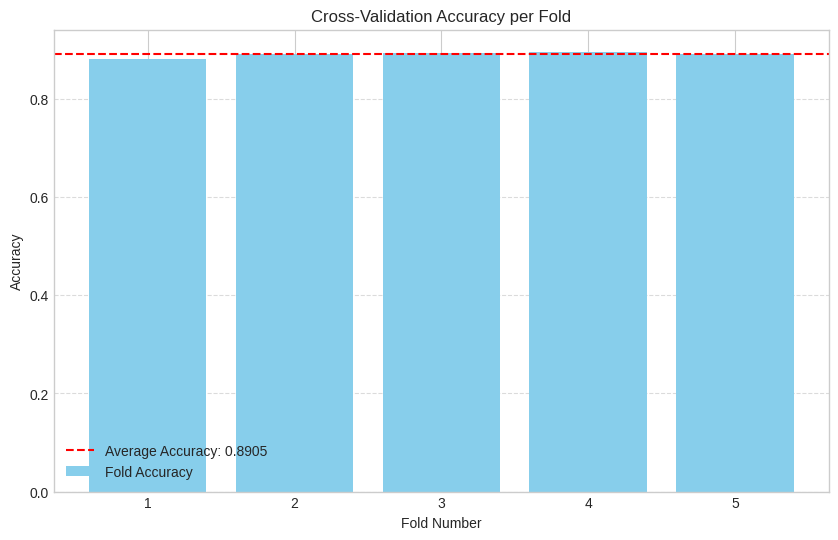

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming cv_scores is available from the previous cross-validation step

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(cv_scores) + 1), cv_scores, color='skyblue', label='Fold Accuracy')
plt.axhline(np.mean(cv_scores), color='red', linestyle='--', label=f'Average Accuracy: {np.mean(cv_scores):.4f}')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Accuracy per Fold')
plt.xticks(range(1, len(cv_scores) + 1))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**CONCLUSIONES PROBLEMA 3**



> Las capas Dropout, aplicadas tras la primera y segunda capa oculta con tasas de 25% y 10%, muestran un comportamiento mucho más equilibrado que la regularización L1+L2 del Problema 2.

> Ambos modelos retrasan el punto de mejor pérdida de validación en comparación con el modelo original (que ocurre en la época 5): las curvas de validación se mantienen relativamente estables durante más épocas antes de comenzar a subir hacia el final del entrenamiento (épocas 15–20), y la precisión de entrenamiento crece de forma más gradual, evitando el ajuste casi perfecto (99%+) que mostraba el modelo original.

> En conjunto, Dropout logra un punto intermedio más razonable que L1+L2: reduce el sobreajuste sin sacrificar tanto la capacidad de aprendizaje del modelo, siendo la técnica más efectiva de las probadas en las tareas 2 y 3 para este problema.
